## Question 1: What is the fundamental idea behind ensemble techniques? How does bagging differ from boosting in terms of approach and objective?

**Answer:**

The fundamental idea behind ensemble techniques is to combine multiple machine learning models to improve prediction accuracy, robustness, and generalization. Instead of relying on a single model, ensemble methods aggregate the predictions of several models to produce a better final result.

**Bagging (Bootstrap Aggregating)** trains multiple models independently using different random subsets of the training data. The final prediction is obtained by averaging (for regression) or majority voting (for classification). Its main objective is to reduce variance and prevent overfitting.

**Boosting** trains models sequentially, where each new model focuses on correcting the errors made by the previous one. The final prediction is obtained by combining the weighted predictions of all models. Its main objective is to reduce bias and improve overall model performance.

---

## Question 2: Explain how the Random Forest Classifier reduces overfitting compared to a single decision tree. Mention the role of two key hyperparameters in this process.

**Answer:**

A Random Forest Classifier reduces overfitting by creating multiple decision trees using different bootstrap samples of the training data and random subsets of features. Instead of relying on a single tree, it combines the predictions of all trees using majority voting, which improves generalization and reduces variance.

Two important hyperparameters are:

- **n_estimators:** Specifies the number of decision trees in the forest. Increasing the number of trees generally improves performance and stability.
- **max_features:** Determines the number of features considered at each split. Using a random subset of features increases diversity among trees and helps reduce overfitting.

---

## Question 3: What is Stacking in ensemble learning? How does it differ from traditional bagging/boosting methods? Provide a simple example use case.

**Answer:**

Stacking is an ensemble learning technique in which multiple different machine learning models are trained as base learners, and their predictions are used as inputs to another model called the meta-learner. The meta-learner combines these predictions to produce the final output.

Unlike bagging and boosting, which usually combine similar models, stacking can combine different types of models such as Decision Trees, Support Vector Machines, and Logistic Regression. This often results in better predictive performance.

**Example:** A credit card fraud detection system may combine the predictions of a Random Forest, SVM, and KNN model using Logistic Regression as the meta-learner to improve classification accuracy.

---

## Question 4: What is the OOB Score in Random Forest, and why is it useful? How does it help in model evaluation without a separate validation set?

**Answer:**

The Out-of-Bag (OOB) Score is an internal evaluation method used in Random Forest. During bootstrap sampling, some training samples are not selected for building a particular decision tree. These unused samples are called Out-of-Bag samples.

The trained tree predicts these OOB samples, and the combined predictions from all trees are used to calculate the OOB Score. It provides an estimate of the model's performance without requiring a separate validation dataset, making efficient use of the available training data.

---

## Question 5: Compare AdaBoost and Gradient Boosting in terms of:
- How they handle errors from weak learners
- Weight adjustment mechanism
- Typical use cases

**Answer:**

| Feature | AdaBoost | Gradient Boosting |
|---------|----------|-------------------|
| **How they handle errors** | Focuses more on misclassified samples in each iteration. | Fits each new model to the residual errors of the previous model. |
| **Weight adjustment mechanism** | Increases the weights of misclassified samples after each iteration. | Optimizes the loss function using gradient descent instead of changing sample weights directly. |
| **Typical use cases** | Spam detection, face detection, and simple classification tasks. | Regression, classification, ranking, and complex predictive modeling. |

---

## Question 6: Why does CatBoost perform well on categorical features without requiring extensive preprocessing? Briefly explain its handling of categorical variables.

**Answer:**

CatBoost is a gradient boosting algorithm that is specifically designed to handle categorical features efficiently. It automatically converts categorical variables into numerical representations using target-based encoding techniques while preventing target leakage through ordered boosting.

As a result, CatBoost does not require extensive preprocessing such as one-hot encoding or label encoding. It works well with datasets containing many categorical features, provides high accuracy, and reduces the risk of overfitting.

## Question 7: KNN Classifier Assignment: Wine Dataset Analysis with Optimization

### Task:
1. Load the Wine dataset (`sklearn.datasets.load_wine()`).
2. Split data into 70% train and 30% test.
3. Train a KNN classifier (default K=5) without scaling and evaluate using:
   - Accuracy
   - Precision, Recall, F1-Score (print classification report)
4. Apply StandardScaler, retrain KNN, and compare metrics.
5. Use GridSearchCV to find the best K (test K=1 to 20) and distance metric (Euclidean, Manhattan).
6. Train the optimized KNN and compare results with the unscaled/scaled versions.

**Answer:**

The following Python program loads the Wine dataset, splits it into training and testing sets, evaluates KNN before and after feature scaling, uses GridSearchCV to find the best value of K and distance metric, and compares the performance of all models.

In [ ]:
# Question 7
# KNN Classifier on Wine Dataset with Optimization

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

# Split dataset (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# -------------------------------
# KNN without Scaling
# -------------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("=== KNN Without Scaling ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# -------------------------------
# KNN with StandardScaler
# -------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)

print("=== KNN With Scaling ===")
print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))

# -------------------------------
# GridSearchCV
# -------------------------------
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

best_knn = grid.best_estimator_

y_best = best_knn.predict(X_test_scaled)

print("=== Optimized KNN ===")
print("Accuracy:", accuracy_score(y_test, y_best))
print(classification_report(y_test, y_best))

## Question 8: PCA + KNN with Variance Analysis and Visualization

### Task:

1. Load the Breast Cancer dataset (`sklearn.datasets.load_breast_cancer()`).
2. Apply PCA and plot the scree plot (explained variance ratio).
3. Retain 95% variance and transform the dataset.
4. Train KNN on the original data and PCA-transformed data, then compare accuracy.
5. Visualize the first two principal components using a scatter plot (color by class).

**Answer:**

The following Python program loads the Breast Cancer dataset, applies Principal Component Analysis (PCA), plots the explained variance ratio (scree plot), retains 95% of the variance, trains KNN classifiers on both the original and PCA-transformed datasets, compares their accuracy, and visualizes the first two principal components.

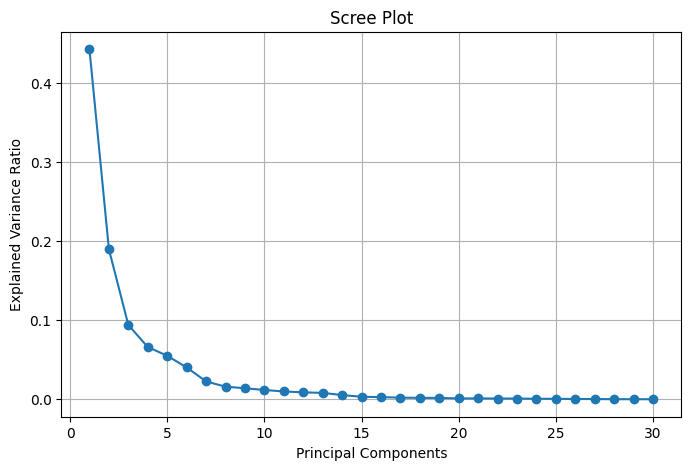

Original Shape : (569, 30)
Transformed Shape : (569, 10)

Accuracy on Original Data : 0.9590643274853801
Accuracy on PCA Data : 0.9649122807017544


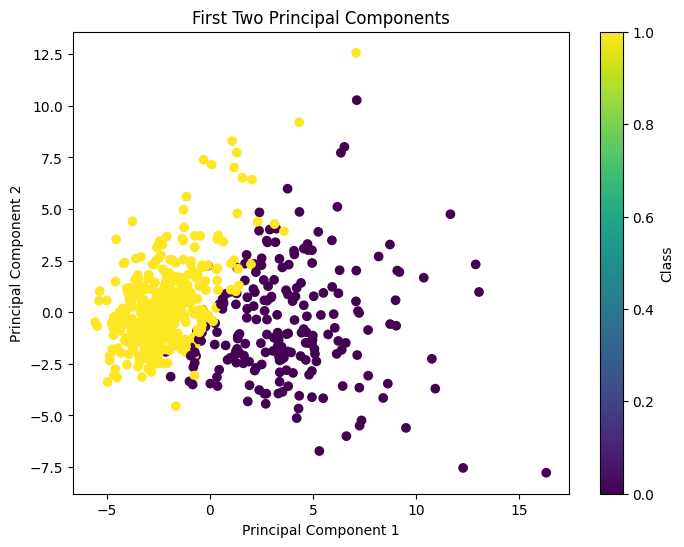

In [1]:
# Question 8
# PCA + KNN with Variance Analysis and Visualization

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Scree Plot
# -------------------------------
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    marker='o'
)
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()

# -------------------------------
# PCA (95% Variance)
# -------------------------------
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original Shape :", X.shape)
print("Transformed Shape :", X_pca.shape)

# -------------------------------
# Original Data
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

knn_original = KNeighborsClassifier()
knn_original.fit(X_train, y_train)

acc_original = accuracy_score(
    y_test,
    knn_original.predict(X_test)
)

# -------------------------------
# PCA Data
# -------------------------------
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

knn_pca = KNeighborsClassifier()
knn_pca.fit(X_train_pca, y_train_pca)

acc_pca = accuracy_score(
    y_test_pca,
    knn_pca.predict(X_test_pca)
)

print("\nAccuracy on Original Data :", acc_original)
print("Accuracy on PCA Data :", acc_pca)

# -------------------------------
# Scatter Plot
# -------------------------------
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='viridis'
)

plt.title("First Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Class")
plt.show()

## Question 9: KNN Regressor with Distance Metrics and K-Value Analysis

### Task:

1. Generate a synthetic regression dataset (`sklearn.datasets.make_regression(n_samples=500, n_features=10)`).
2. Train a KNN regressor with:
   - Euclidean distance (K=5)
   - Manhattan distance (K=5)
   - Compare Mean Squared Error (MSE) for both.
3. Test K=1, 5, 10, 20, 50 and plot K vs. MSE to analyze bias-variance tradeoff.

**Answer:**

The following Python program generates a synthetic regression dataset, trains KNN Regressor models using Euclidean and Manhattan distance metrics, compares their Mean Squared Error (MSE), evaluates different values of K, and plots K versus MSE to analyze the bias-variance tradeoff.

Euclidean MSE : 4803.90558674207
Manhattan MSE : 5210.225816542467


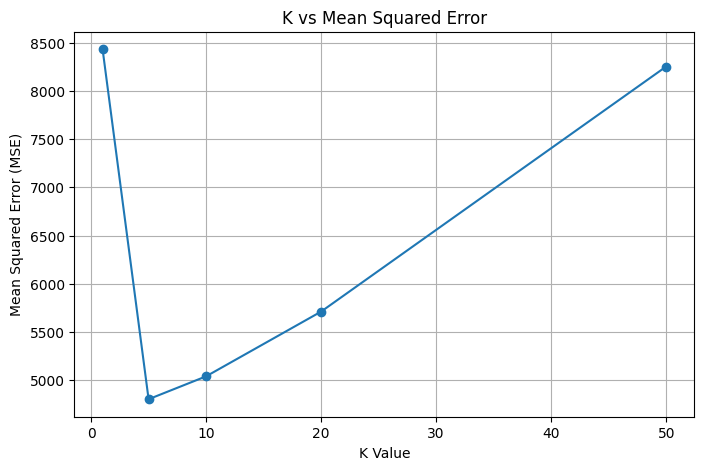

In [2]:
# Question 9
# KNN Regressor with Distance Metrics and K-Value Analysis

import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Generate synthetic regression dataset
X, y = make_regression(
    n_samples=500,
    n_features=10,
    noise=10,
    random_state=42
)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -------------------------------
# Euclidean Distance (K=5)
# -------------------------------
knn_euclidean = KNeighborsRegressor(
    n_neighbors=5,
    metric='euclidean'
)
knn_euclidean.fit(X_train, y_train)

pred_euclidean = knn_euclidean.predict(X_test)
mse_euclidean = mean_squared_error(y_test, pred_euclidean)

# -------------------------------
# Manhattan Distance (K=5)
# -------------------------------
knn_manhattan = KNeighborsRegressor(
    n_neighbors=5,
    metric='manhattan'
)
knn_manhattan.fit(X_train, y_train)

pred_manhattan = knn_manhattan.predict(X_test)
mse_manhattan = mean_squared_error(y_test, pred_manhattan)

print("Euclidean MSE :", mse_euclidean)
print("Manhattan MSE :", mse_manhattan)

# -------------------------------
# K vs MSE Analysis
# -------------------------------
k_values = [1, 5, 10, 20, 50]
mse_values = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    mse = mean_squared_error(y_test, prediction)
    mse_values.append(mse)

plt.figure(figsize=(8,5))
plt.plot(k_values, mse_values, marker='o')
plt.title("K vs Mean Squared Error")
plt.xlabel("K Value")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)
plt.show()

## Question 10: KNN with KD-Tree/Ball Tree, Imputation, and Real-World Data

### Task:

1. Load the Pima Indians Diabetes dataset (contains missing values).
2. Use KNN Imputation (sklearn.impute.KNNImputer) to fill missing values.
3. Train KNN using:
   - Brute-force method
   - KD-Tree
   - Ball Tree
4. Compare their training time and accuracy.
5. Plot the decision boundary for the best-performing method (use 2 most important features).

**Answer:**

The following Python program loads the Pima Indians Diabetes dataset, handles missing values using KNN Imputer, trains KNN classifiers using Brute-force, KD-Tree, and Ball Tree algorithms, compares their training time and accuracy, and visualizes the decision boundary of the best-performing model using two important features.

Algorithm Comparison
------------------------------------
brute       Time: 0.001057s   Accuracy: 0.6753
kd_tree     Time: 0.001655s   Accuracy: 0.6753
ball_tree   Time: 0.004334s   Accuracy: 0.6753

Best Algorithm: brute


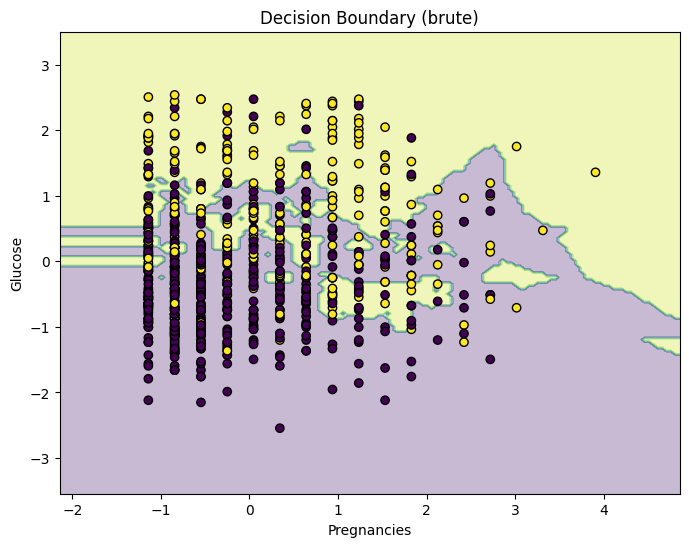

In [3]:
# Question 10
# KNN with KD-Tree/Ball Tree, Imputation, and Real-World Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ---------------------------------------
# Load Dataset
# ---------------------------------------
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies","Glucose","BloodPressure","SkinThickness",
    "Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"
]

df = pd.read_csv(url, names=columns)

# Replace impossible zeros with NaN
for col in ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]:
    df[col] = df[col].replace(0, np.nan)

# ---------------------------------------
# KNN Imputation
# ---------------------------------------
imputer = KNNImputer(n_neighbors=5)
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# ---------------------------------------
# Features and Target
# ---------------------------------------
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# ---------------------------------------
# Compare Algorithms
# ---------------------------------------
algorithms = ["brute", "kd_tree", "ball_tree"]

results = []

for algo in algorithms:
    model = KNeighborsClassifier(
        n_neighbors=5,
        algorithm=algo
    )

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    results.append([algo, train_time, acc])

print("Algorithm Comparison")
print("------------------------------------")
for r in results:
    print(f"{r[0]:10}  Time: {r[1]:.6f}s   Accuracy: {r[2]:.4f}")

# ---------------------------------------
# Best Model
# ---------------------------------------
best_algo = max(results, key=lambda x: x[2])[0]

print("\nBest Algorithm:", best_algo)

best_model = KNeighborsClassifier(
    n_neighbors=5,
    algorithm=best_algo
)

# Use only first two features for visualization
X2 = X[:, :2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y,
    test_size=0.3,
    random_state=42
)

best_model.fit(X_train2, y_train2)

# ---------------------------------------
# Decision Boundary
# ---------------------------------------
x_min, x_max = X2[:,0].min()-1, X2[:,0].max()+1
y_min, y_max = X2[:,1].min()-1, X2[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.05),
    np.arange(y_min, y_max, 0.05)
)

Z = best_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X2[:,0],
    X2[:,1],
    c=y,
    edgecolor="k"
)

plt.xlabel("Pregnancies")
plt.ylabel("Glucose")
plt.title("Decision Boundary (" + best_algo + ")")
plt.show()